In [12]:
import numpy as np
import json
import pickle

from sklearn.datasets import make_multilabel_classification

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression as  BasePredictor

import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [2]:
import sys
sys.path.append("..")

In [3]:
from src.data.formatting import resample_data_set
from src.conformal_risk_control.fnr import compute_prediction_set
from src.model_selection.fnr_oracle import compute_oracle_prediction_set
from src.model_selection.fnr_upper import compute_upper_prediction_set
from src.model_selection.fnr_split import select_predictor_index

In [4]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [5]:
def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

In [6]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_features=params["feature_number"],
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [7]:
params_global = reader("params/experiment_2.json")

{'data': {'sample_size': 500, 'feature_number': 300, 'label_number': 10, 'avg_label_number': 4, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'log_lam_min': -2, 'log_lam_max': 4, 'lam_numbers': [50, 100, 200, 400]}, 'risk': {'control_level': 0.25}}


In [11]:
parameter_grids = [
    [
        {"C":1/lam} for lam in np.logspace(
            params_global["predictor"]["log_lam_min"],
            params_global["predictor"]["log_lam_max"],
            lam_number,
        )
    ]
    for lam_number in params_global["predictor"]["lam_numbers"]
]

In [13]:
predictors_ = [
    [
        OneVsRestClassifier(BasePredictor(**parameter)) for parameter in parameter_grid    
    ] for parameter_grid in parameter_grids
]

In [14]:
rep_number = 100

In [15]:
results_ = [
        {
        "size":{
            "Oracle":[],
            "Upper":[],
            "Split":[],
            "Output":[],
        }, "FNR":{
            "Oracle":[],
            "Upper":[],
            "Split":[],
        }
    } for _ in predictors_
]

In [16]:
results_

[{'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}},
 {'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}},
 {'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}},
 {'size': {'Oracle': [], 'Upper': [], 'Split': [], 'Output': []},
  'FNR': {'Oracle': [], 'Upper': [], 'Split': []}}]

In [17]:
for predictors, results in zip(predictors_, results_):
    for rep_index in tqdm(range(rep_number)):
        inputs_, outputs_ = generate_data_set(params_global["data"])
    
        (
            (scaled_inputs_train, outputs_train),
            (scaled_inputs_calibration, outputs_calibration),
            (
                scaled_inputs_selection,
                scaled_inputs_proper_cal,
                outputs_selection,
                outputs_proper_cal,
            ),
            (scaled_input_test, output_test),
        ) = resample_data_set(inputs_, outputs_, params_global["data"]["cal_size"], params_global["data"]["proper_cal_size"])
    
    
        for predictor in predictors:
            predictor.fit(scaled_inputs_train, outputs_train)
    
    
        probas_calibration_per_predictor = [
            predictor.predict_proba(scaled_inputs_calibration) for predictor in predictors
        ]
        proba_test_per_predictor = [
            predictor.predict_proba(scaled_input_test) for predictor in predictors
        ]
        oracle_prediction_set = compute_oracle_prediction_set(
            outputs_calibration,
            probas_calibration_per_predictor,
            output_test,
            proba_test_per_predictor,
            params_global["risk"]["control_level"],
        )
    
        
        upper_prediction_set = compute_upper_prediction_set(
            outputs_calibration,
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            params_global["risk"]["control_level"],
        )
    
    
    
        probas_selection_per_predictor = [
            predictor.predict_proba(scaled_inputs_selection) for predictor in predictors
        ]
        split_predictor_index = select_predictor_index(
            outputs_selection, probas_selection_per_predictor, params_global["risk"]["control_level"]
        )
        split_prediction_set = compute_prediction_set(
            predictors[split_predictor_index],
            scaled_inputs_proper_cal,
            outputs_proper_cal,
            scaled_input_test,
            params_global["risk"]["control_level"]
        )
    
        oracle_fnr = (
            np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
            / output_test.sum(axis=1)
        ).item()
        upper_fnr = (
            np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
            / output_test.sum(axis=1)
        ).item()
        split_fnr = (
            np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
            / output_test.sum(axis=1)
        ).item()
        
        results["FNR"]["Oracle"].append(oracle_fnr)
        results["FNR"]["Upper"].append(upper_fnr)
        results["FNR"]["Split"].append(split_fnr)
    
        results["size"]["Oracle"].append(oracle_prediction_set.sum())
        results["size"]["Upper"].append(upper_prediction_set.sum())
        results["size"]["Split"].append(split_prediction_set.sum())
        results["size"]["Output"].append(output_test.sum())
    
        
        print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
        print("Average output size: {}".format(np.mean(results["size"]["Output"])))
        print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
        print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))


  1%|          | 1/100 [00:03<05:09,  3.13s/it]

Average oracle prediction-set size: 7.0
Average output size: 5.0
Average split prediction-set size: 6.0
Average upper prediction-set size: 7.0


  2%|▏         | 2/100 [00:06<05:00,  3.06s/it]

Average oracle prediction-set size: 6.5
Average output size: 4.5
Average split prediction-set size: 6.0
Average upper prediction-set size: 6.5


  3%|▎         | 3/100 [00:09<04:53,  3.03s/it]

...

Average oracle prediction-set size: 5.051020408163265
Average output size: 3.7346938775510203
Average split prediction-set size: 5.224489795918367
Average upper prediction-set size: 5.591836734693878


 99%|█████████▉| 99/100 [39:49<00:23, 23.48s/it]

Average oracle prediction-set size: 5.0606060606060606
Average output size: 3.757575757575758
Average split prediction-set size: 5.232323232323233
Average upper prediction-set size: 5.595959595959596


100%|██████████| 100/100 [40:13<00:00, 24.14s/it]

Average oracle prediction-set size: 5.07
Average output size: 3.73
Average split prediction-set size: 5.24
Average upper prediction-set size: 5.6


In [18]:
for results in results_:
    print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
    print("Average output size: {}".format(np.mean(results["size"]["Output"])))
    print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
    print("Average upper prediction-set      size: {}".format(np.mean(results["size"]["Upper"])))
    print("\n")

Average oracle prediction-set size: 4.92
Average output size: 4.5
Average split prediction-set size: 5.15
Average upper prediction-set size: 5.33


Average oracle prediction-set size: 5.24
Average output size: 4.06
Average split prediction-set size: 5.4
Average upper prediction-set size: 5.59


Average oracle prediction-set size: 5.03
Average output size: 3.98
Average split prediction-set size: 5.34
Average upper prediction-set size: 5.47


Average oracle prediction-set size: 5.07
Average output size: 3.73
Average split prediction-set size: 5.24
Average upper prediction-set size: 5.6




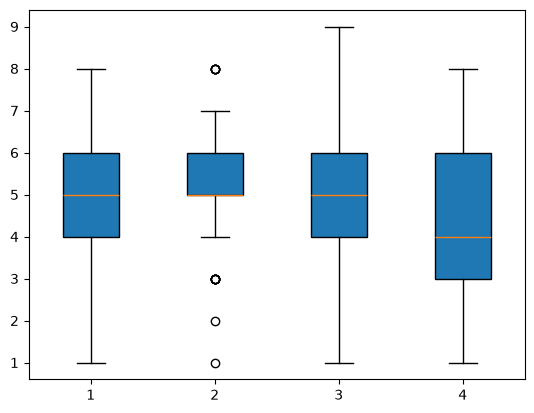

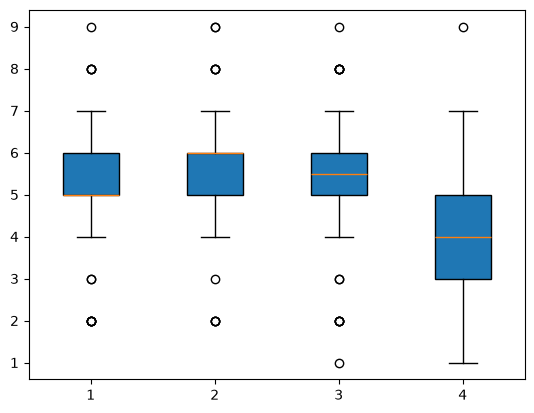

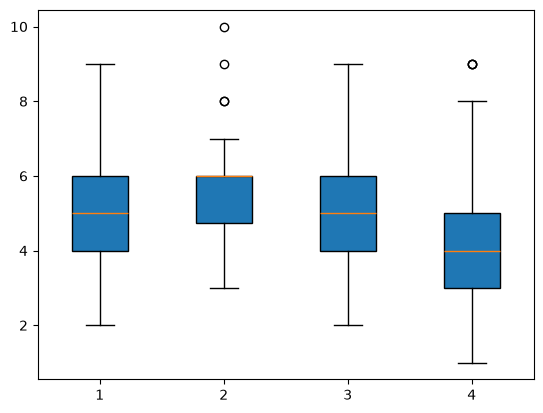

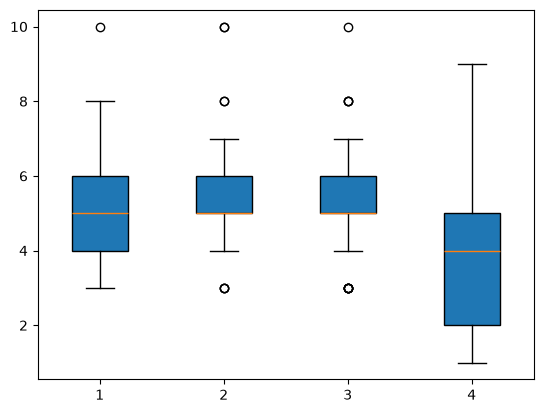

In [19]:
for results in results_:
    df_volume = pd.DataFrame.from_dict(
        results["size"]
    )
    fig, ax = plt.subplots()
    box = ax.boxplot(df_volume, patch_artist=True)

In [20]:
for results in results_:
    print("Average oracle prediction-set FNR: {}".format(np.mean(results["FNR"]["Oracle"])))
    print("Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"])))
    print("Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"])))
    print("\n")

Average oracle prediction-set FNR: 0.2651309523809524
Average split prediction-set FNR: 0.23170238095238094
Average upper prediction-set FNR: 0.23341666666666666


Average oracle prediction-set FNR: 0.2618968253968254
Average split prediction-set FNR: 0.24567460317460316
Average upper prediction-set FNR: 0.22456349206349205


Average oracle prediction-set FNR: 0.270031746031746
Average split prediction-set FNR: 0.2363928571428571
Average upper prediction-set FNR: 0.2339365079365079


Average oracle prediction-set FNR: 0.26555555555555554
Average split prediction-set FNR: 0.2591269841269841
Average upper prediction-set FNR: 0.22096031746031744




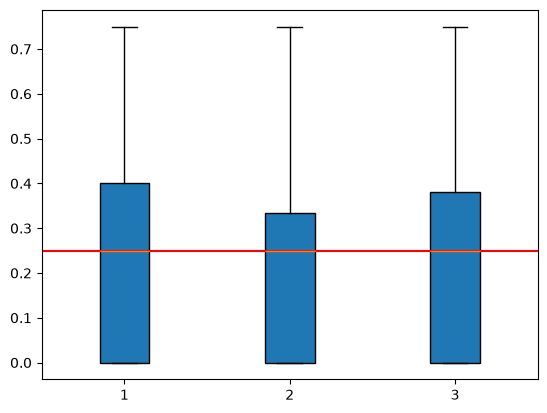

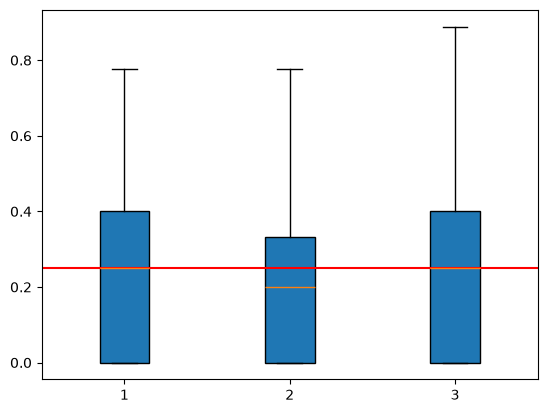

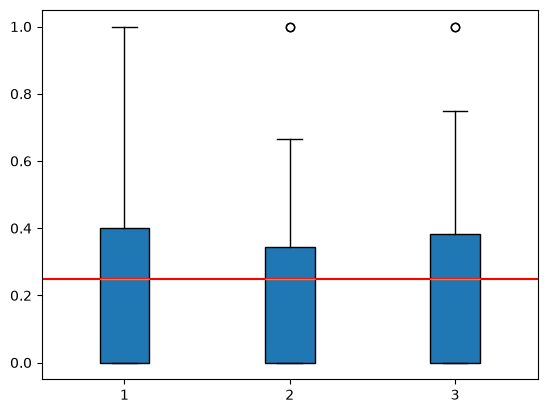

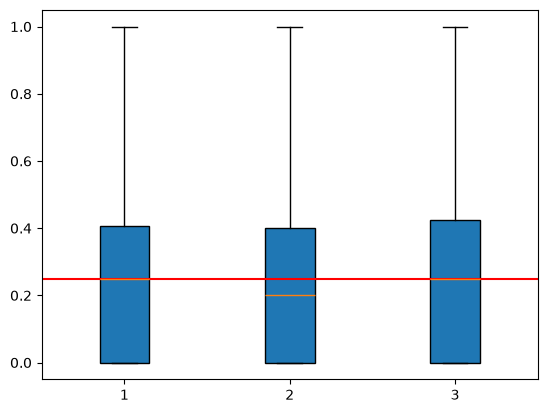

In [21]:
for results in results_:
    df_fnr = pd.DataFrame.from_dict(
        results["FNR"]
    )
    fig, ax = plt.subplots()
    box = ax.boxplot(df_fnr, patch_artist=True)
    ax.plot(
        [1-0.5, 3+0.5],
        [params_global["risk"]["control_level"], params_global["risk"]["control_level"]],
        color="red"
    )

In [ ]:
result_path = "results/"
result_name = "experiment_2.pkl"
save_list_with_pickle(results_, result_path + result_name)